# Advanced Acoustic Noise Injection

## The Clinical Problem
Model brittle-ness occurs when algorithms memorize the "clinical silence" of a pristine dataset. When deployed in a Neonatal Intensive Care Unit (NICU), alarms, talking, and HVAC systems absolutely shatter accuracy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa, librosa.display
from src.utils import CLEANED_DIR, NOISY_DIR, discover_audio_files
from src.noise_augmentation import augment_dataset, add_gaussian_noise, add_background_noise, time_shift
import warnings; warnings.filterwarnings("ignore")

clean_file = discover_audio_files(CLEANED_DIR)[0][0]
y_c, sr = librosa.load(clean_file, sr=16000)
y_pink = add_background_noise(y_c, snr_db=15)
y_gauss = add_gaussian_noise(y_c, snr_db=15)

### 1. Spectrogram Error Map (Subtraction Matrix)

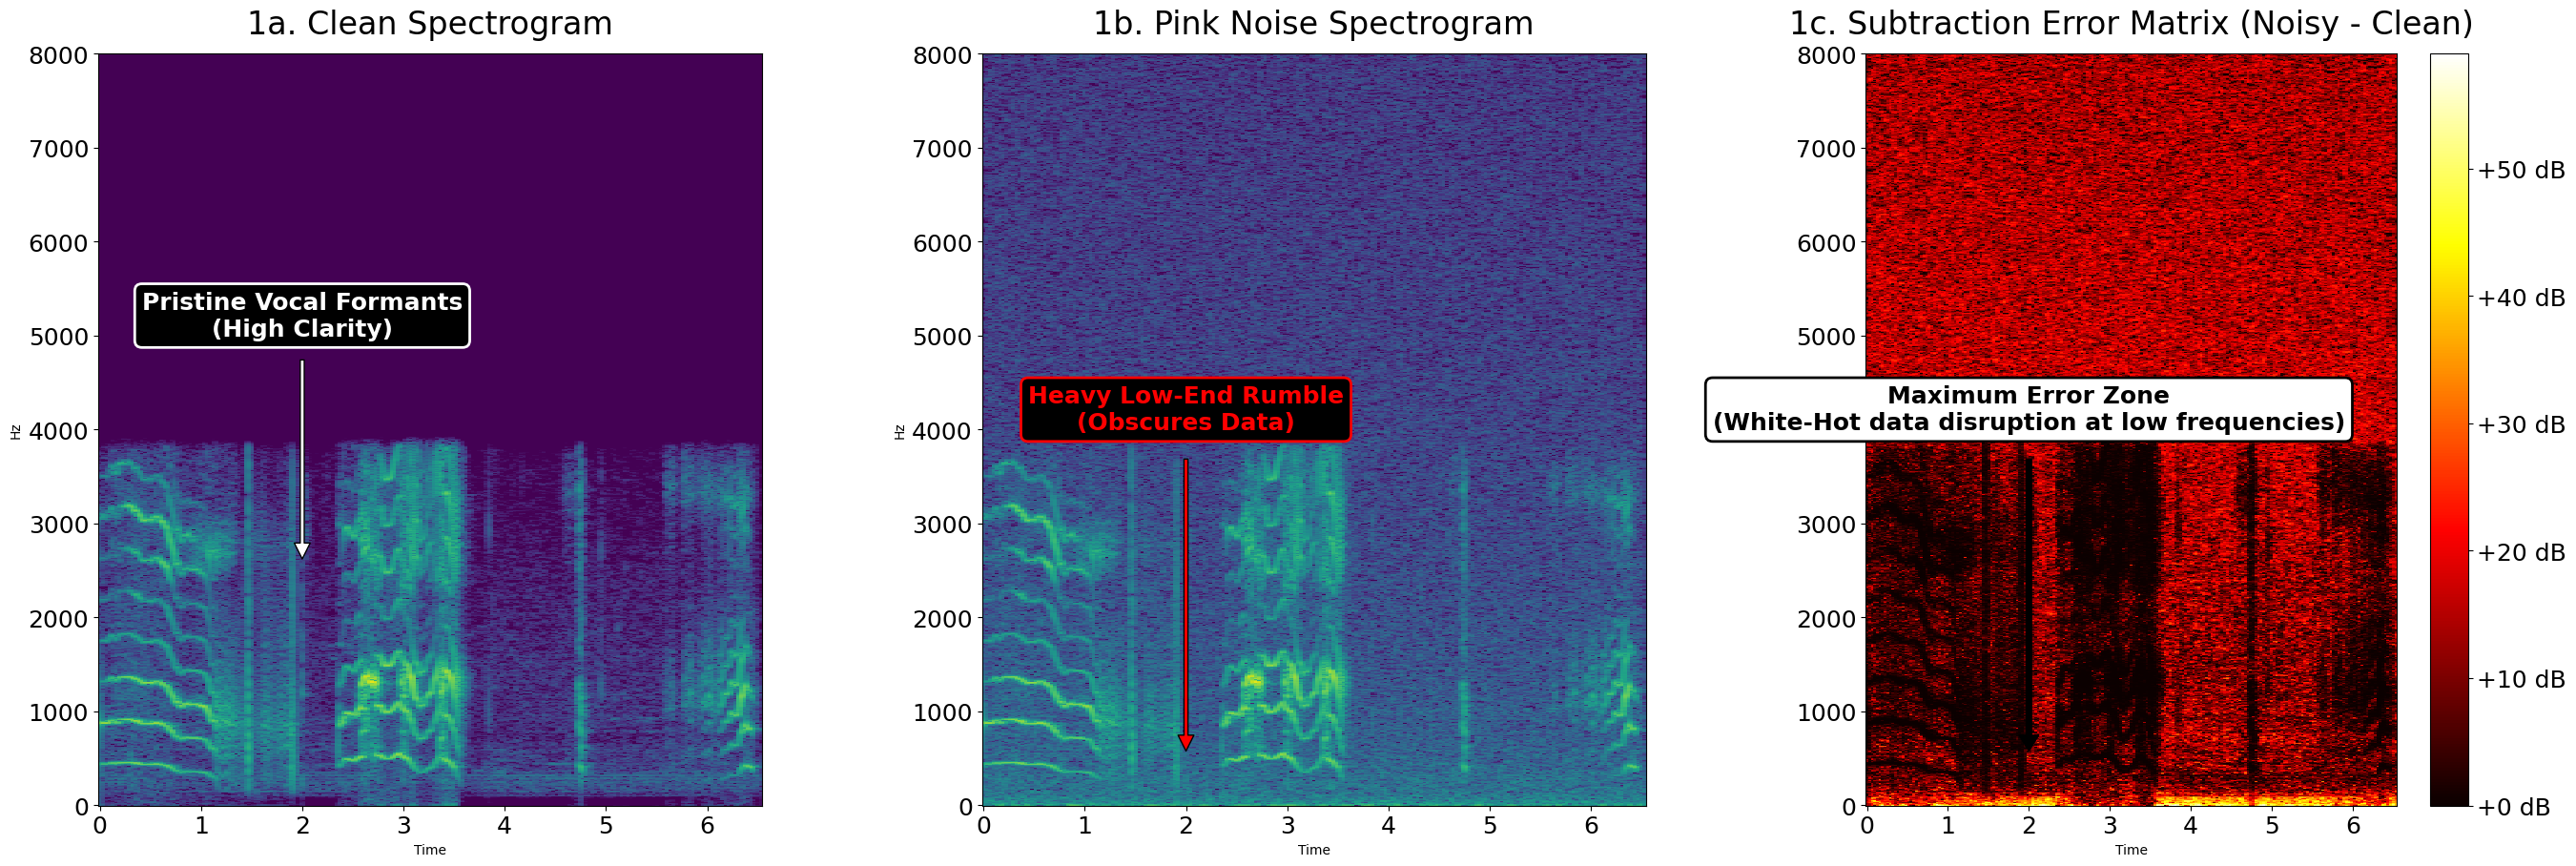

In [2]:
D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_c)), ref=np.max)
D_pink = librosa.amplitude_to_db(np.abs(librosa.stft(y_pink)), ref=np.max)
error_matrix = np.abs(D_clean - D_pink)

fig, axes = plt.subplots(1, 3, figsize=(28, 10))
y_ax_max = 8000 # Spectrograms plot to True Nyquist (8000Hz)

librosa.display.specshow(D_clean, sr=sr, y_axis='linear', x_axis='time', ax=axes[0], cmap="viridis")
axes[0].set_title("1a. Clean Spectrogram", fontsize=24, pad=15)
axes[0].tick_params(labelsize=18)

# ANNOTATE 1A: Point to the bright vertical stripes (Formants) at exactly t=2.0s, f=2500Hz.
axes[0].annotate("Pristine Vocal Formants\n(High Clarity)", 
            xy=(2.0, 2500), xytext=(2.0, 5000), 
            arrowprops=dict(facecolor="white", shrink=0.05, width=3, headwidth=12), 
            fontsize=18, fontweight="bold", color="white", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="white", lw=2))

librosa.display.specshow(D_pink, sr=sr, y_axis='linear', x_axis='time', ax=axes[1], cmap="viridis")
axes[1].set_title("1b. Pink Noise Spectrogram", fontsize=24, pad=15)
axes[1].tick_params(labelsize=18)

# ANNOTATE 1B: Point strictly to the bottom edge where pink noise lives (t=2.0s, f=400Hz).
axes[1].annotate("Heavy Low-End Rumble\n(Obscures Data)", 
            xy=(2.0, 400), xytext=(2.0, 4000), 
            arrowprops=dict(facecolor="red", shrink=0.05, width=3, headwidth=12), 
            fontsize=18, fontweight="bold", color="red", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="red", lw=2))

img = librosa.display.specshow(error_matrix, sr=sr, y_axis='linear', x_axis='time', ax=axes[2], cmap="hot")
axes[2].set_title("1c. Subtraction Error Matrix (Noisy - Clean)", fontsize=24, pad=15)
axes[2].tick_params(labelsize=18)
cbar = fig.colorbar(img, ax=axes[2], format="%+2.f dB")
cbar.ax.tick_params(labelsize=18)

# ANNOTATE 1C: Point to the bright white-hot bottom line.
axes[2].annotate("Maximum Error Zone\n(White-Hot data disruption at low frequencies)", 
            xy=(2.0, 400), xytext=(2.0, 4000), 
            arrowprops=dict(facecolor="black", shrink=0.05, width=4, headwidth=15), 
            fontsize=18, fontweight="bold", color="black", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=2))

plt.tight_layout(pad=4.0)
plt.show()

**Advanced Interpretation:** The "Error Matrix" (1c) exposes the 1/f nature of Pink Noise. The bottom edge (low frequencies) is glowing bright red/white, indicating massive data disruption from the injected rumble. The model learns to ignore this low-end rumble while preserving high-pitch cry peaks.

### 2. Frequency Profile Analytics

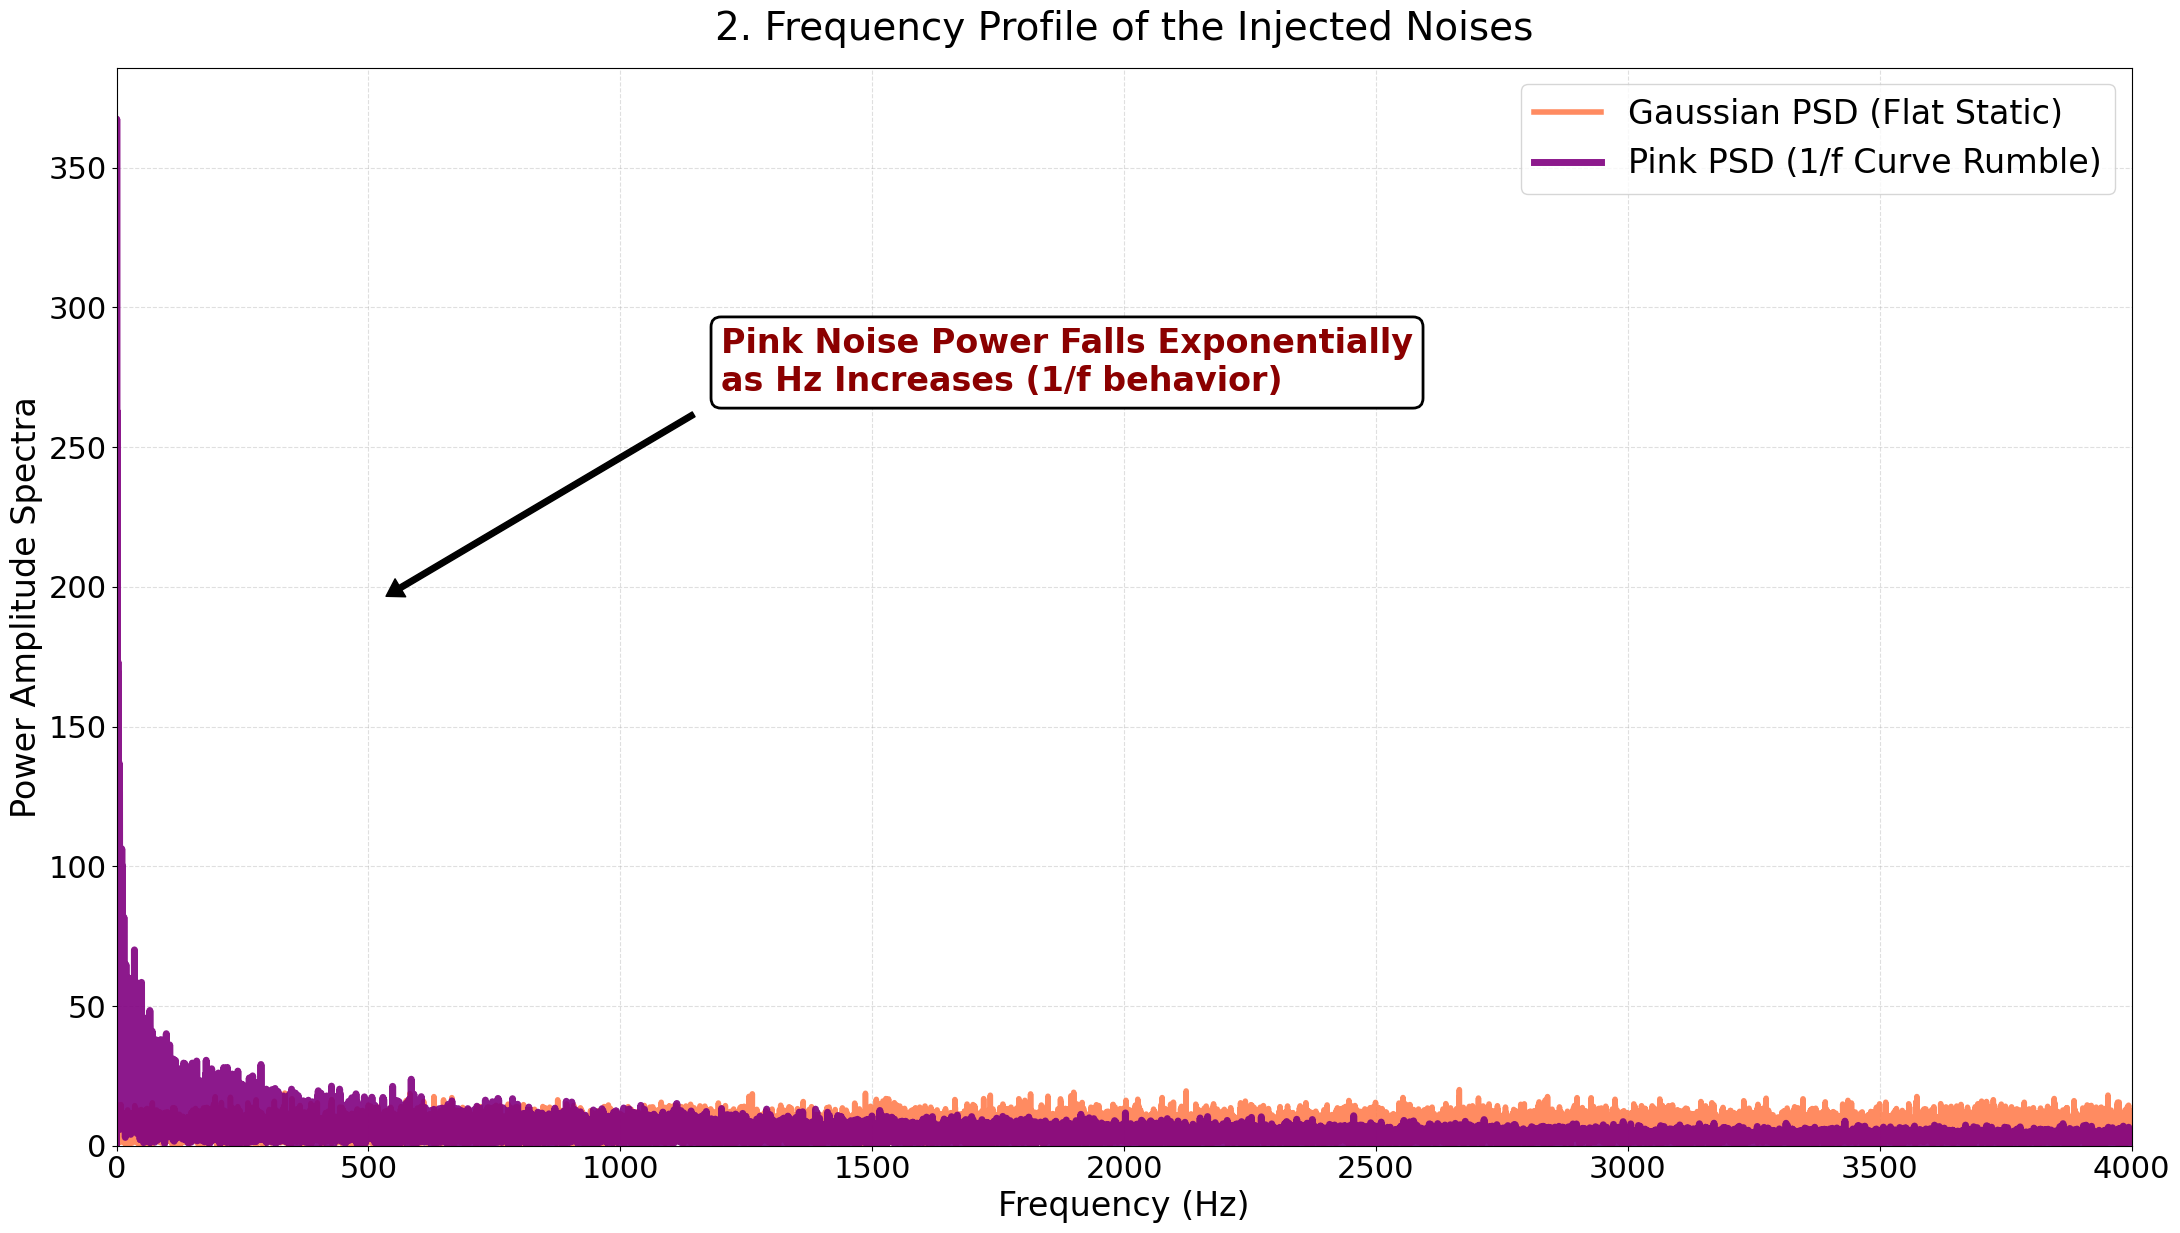

In [3]:
fig, ax = plt.subplots(figsize=(26, 14))
freqs = np.fft.rfftfreq(len(y_c), d=1/sr)
fft_gauss = np.abs(np.fft.rfft(y_gauss-y_c))
fft_pink = np.abs(np.fft.rfft(y_pink-y_c))

ax.plot(freqs, fft_gauss, color="coral", alpha=0.9, lw=4, label="Gaussian PSD (Flat Static)")
ax.plot(freqs, fft_pink, color="purple", alpha=0.9, lw=5, label="Pink PSD (1/f Curve Rumble)")

ax.set_xlim(0, 4000)
y_max = np.max(fft_pink) * 1.05
ax.set_ylim(0, y_max)
ax.set_title("2. Frequency Profile of the Injected Noises", fontsize=28, pad=20)
ax.set_xlabel("Frequency (Hz)", fontsize=24)
ax.set_ylabel("Power Amplitude Spectra", fontsize=24)
ax.tick_params(labelsize=22)
ax.legend(loc="upper right", fontsize=24)
ax.grid(True, alpha=0.4, linestyle="--")

# Point to the sharp downward curve of pink noise at 500Hz
ax.annotate("Pink Noise Power Falls Exponentially\nas Hz Increases (1/f behavior)", 
            xy=(500, y_max*0.5), xytext=(1200, y_max*0.7), 
            arrowprops=dict(facecolor="black", shrink=0.05, width=4, headwidth=15), 
            fontsize=24, fontweight="bold", color="darkred", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=2))

plt.show()

**Advanced Interpretation:** Zooming strictly into the 0-4kHz band proves the exact mathematical injection. The coral line (Gaussian) is completely flat (equal acoustic energy across all frequencies). The purple line (Pink noise) begins massively high near 0Hz but plummets brutally toward 0. This visualizes realistic hospital "hum" perfectly.